Dataset shape: (10000, 14)

Columns: ['age', 'gender', 'bmi', 'hbA1c', 'systolic_bp', 'diastolic_bp', 'years_with_diabetes', 'smoking_status', 'hypertension', 'dyslipidemia', 'family_history_dr', 'serum_cholesterol', 'retinal_screening_regularity', 'referable_DR_risk']

Missing values:
age                             0
gender                          0
bmi                             0
hbA1c                           0
systolic_bp                     0
diastolic_bp                    0
years_with_diabetes             0
smoking_status                  0
hypertension                    0
dyslipidemia                    0
family_history_dr               0
serum_cholesterol               0
retinal_screening_regularity    0
referable_DR_risk               0
dtype: int64

Data types:
age                               int64
gender                            int64
bmi                             float64
hbA1c                           float64
systolic_bp                     float64
diastolic_b

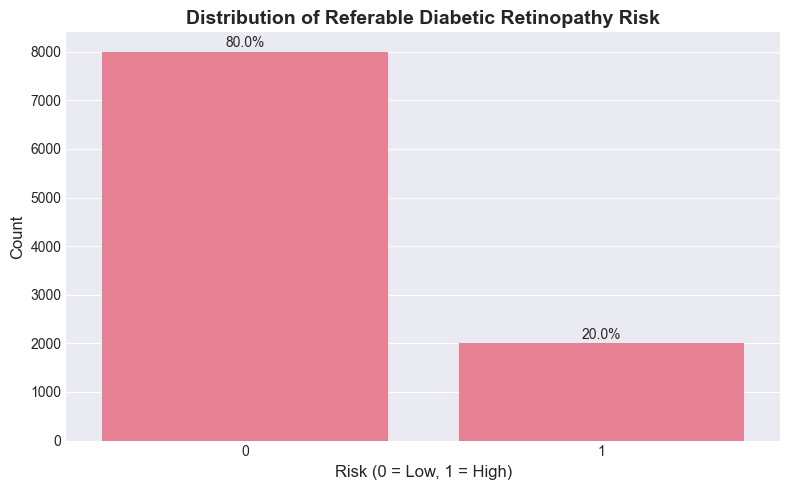


Statistical summary for numerical features:
            age       bmi     hbA1c  systolic_bp  diastolic_bp  \
count  10000.00  10000.00  10000.00     10000.00      10000.00   
mean      57.48     28.52      7.79       134.99         84.99   
std       12.04      5.00      1.81        19.97         11.97   
min       10.00      9.22     -0.24        49.09         43.94   
25%       49.00     25.09      6.55       121.27         77.00   
50%       57.00     28.52      7.80       135.03         85.07   
75%       66.00     31.94      9.02       148.53         93.01   
max      105.00     50.90     14.51       205.73        129.94   

       years_with_diabetes  serum_cholesterol  
count             10000.00           10000.00  
mean                  7.98             194.67  
std                   7.86              35.01  
min                   0.00              65.32  
25%                   2.34             171.45  
50%                   5.62             194.36  
75%                  11.

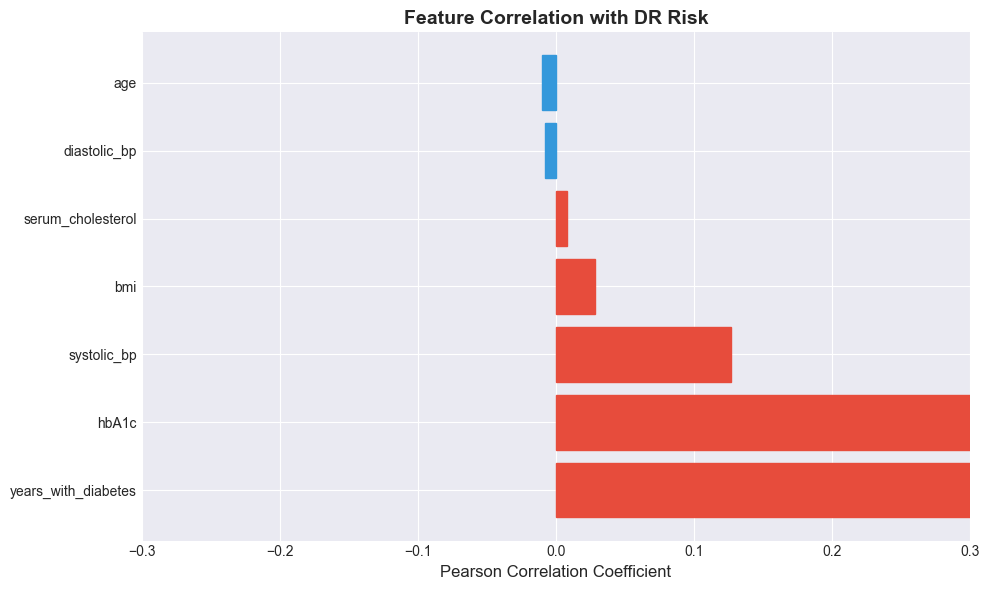

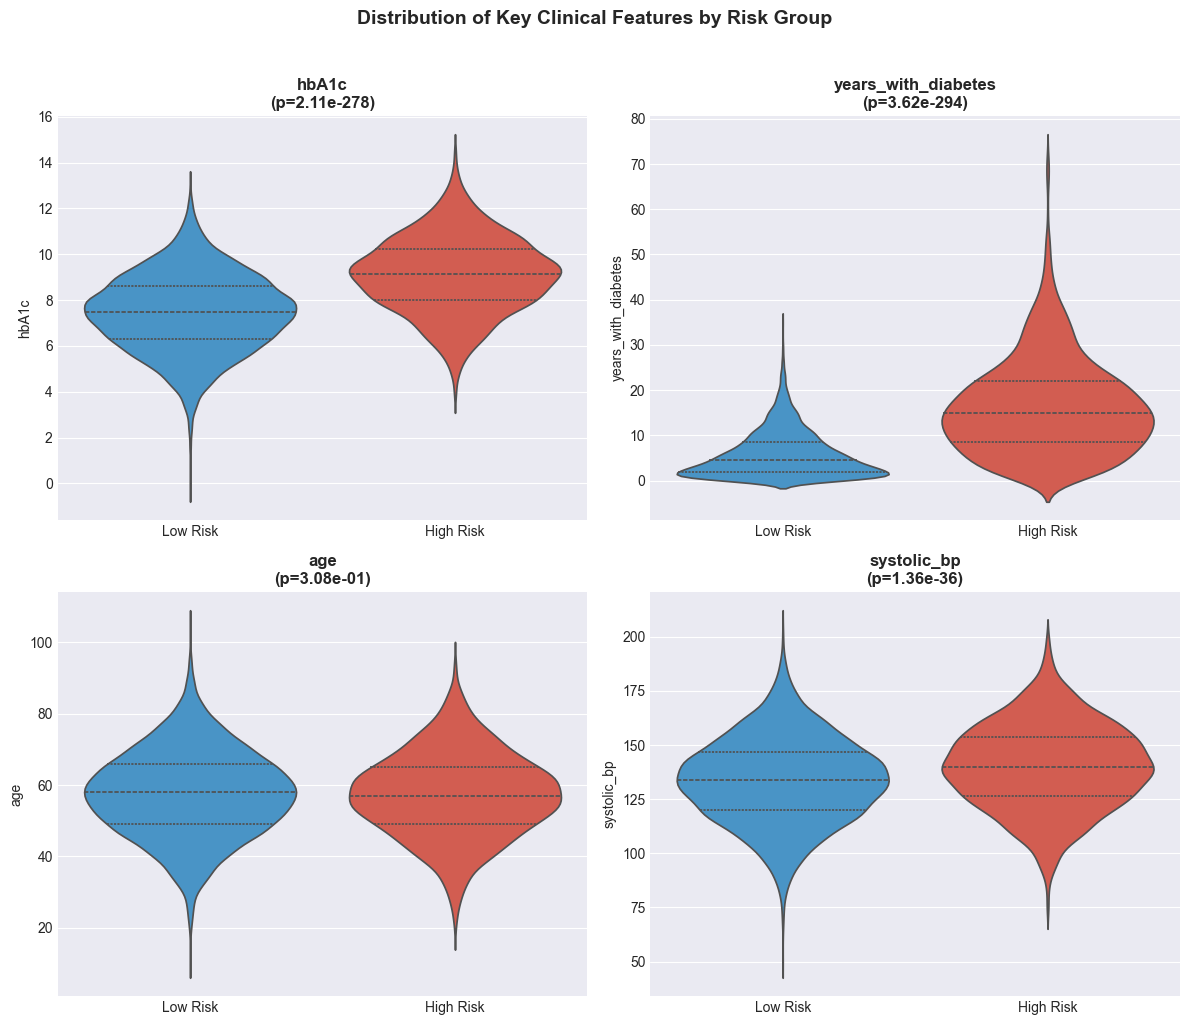

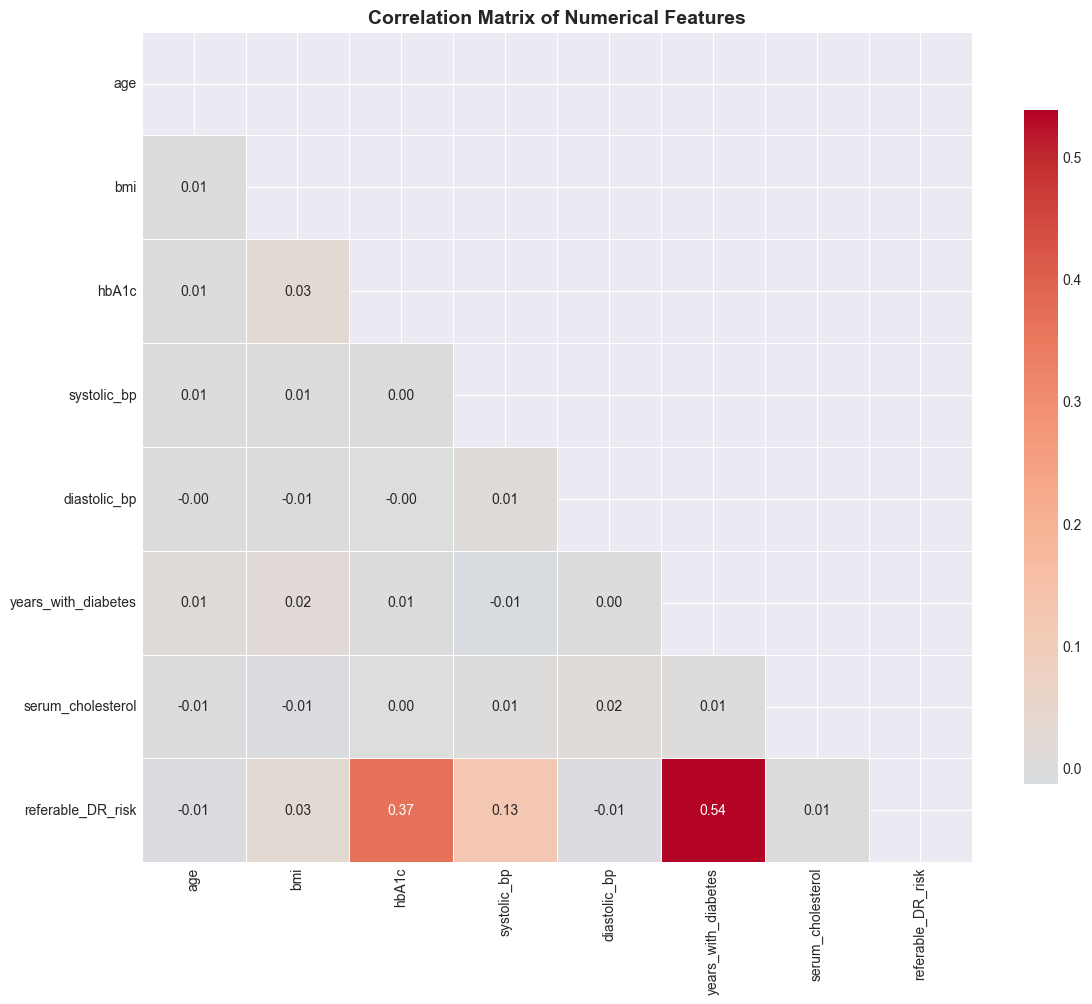


=== KEY INSIGHTS ===

Dataset Shape:
(10000, 14)

Class Balance:
{0: 0.8, 1: 0.2}

Top Correlated Features:
[{'Feature': 'years_with_diabetes', 'Correlation': 0.5384118053368555}, {'Feature': 'hbA1c', 'Correlation': 0.3658690725706737}, {'Feature': 'systolic_bp', 'Correlation': 0.12644776915092176}]

Key Findings:
1. HbA1c and years_with_diabetes show highest positive correlation with DR risk
2. High-risk patients are older with higher blood pressure
3. Regular retinal screening appears protective (negative correlation)
4. No missing values in the dataset


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load data
df = pd.read_csv('../data/diabetic_retinopathy_data.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nData types:\n{df.dtypes}")

# Class distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='referable_DR_risk', data=df)
plt.title('Distribution of Referable Diabetic Retinopathy Risk', fontsize=14, fontweight='bold')
plt.xlabel('Risk (0 = Low, 1 = High)', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Add percentage labels
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2
    y = p.get_height() + 0.01 * total
    ax.annotate(percentage, (x, y), ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('../figures/class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Statistical summary for numerical features
numerical_cols = ['age', 'bmi', 'hbA1c', 'systolic_bp', 'diastolic_bp', 
                  'years_with_diabetes', 'serum_cholesterol']
print(f"\nStatistical summary for numerical features:")
print(df[numerical_cols].describe().round(2))

# Correlation with target
print(f"\nCorrelation with target (referable_DR_risk):")
correlations = {}
for col in numerical_cols:
    corr = df[col].corr(df['referable_DR_risk'])
    correlations[col] = corr
    print(f"{col}: {corr:.3f}")

# Visualize correlations
corr_df = pd.DataFrame(list(correlations.items()), columns=['Feature', 'Correlation'])
corr_df = corr_df.sort_values('Correlation', ascending=False)

plt.figure(figsize=(10, 6))
bars = plt.barh(corr_df['Feature'], corr_df['Correlation'])
plt.title('Feature Correlation with DR Risk', fontsize=14, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient', fontsize=12)
plt.xlim(-0.3, 0.3)

# Color bars by direction
for bar, corr in zip(bars, corr_df['Correlation']):
    if corr > 0:
        bar.set_color('#e74c3c')  # Red for positive
    else:
        bar.set_color('#3498db')  # Blue for negative

plt.tight_layout()
plt.savefig('../figures/correlation_with_target.png', dpi=300, bbox_inches='tight')
plt.show()

# Distribution of key clinical features by risk group
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()

key_features = ['hbA1c', 'years_with_diabetes', 'age', 'systolic_bp']

for idx, feature in enumerate(key_features):
    ax = axes[idx]
    
    # Create violin plot
    sns.violinplot(x='referable_DR_risk', y=feature, data=df, ax=ax, 
                   palette=['#3498db', '#e74c3c'], inner='quartile')
    
    # Add statistical test
    low_risk = df[df['referable_DR_risk'] == 0][feature]
    high_risk = df[df['referable_DR_risk'] == 1][feature]
    t_stat, p_value = stats.ttest_ind(low_risk, high_risk, equal_var=False)
    
    ax.set_title(f'{feature}\n(p={p_value:.2e})', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_xticklabels(['Low Risk', 'High Risk'])
    ax.set_ylabel(feature, fontsize=10)

plt.suptitle('Distribution of Key Clinical Features by Risk Group', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../figures/feature_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

# Correlation matrix heatmap
plt.figure(figsize=(12, 10))
corr_matrix = df[numerical_cols + ['referable_DR_risk']].corr()

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})

plt.title('Correlation Matrix of Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Save key insights
insights = {
    'dataset_shape': df.shape,
    'class_balance': df['referable_DR_risk'].value_counts(normalize=True).to_dict(),
    'top_correlated_features': corr_df.head(3).to_dict('records'),
    'key_findings': [
        "HbA1c and years_with_diabetes show highest positive correlation with DR risk",
        "High-risk patients are older with higher blood pressure",
        "Regular retinal screening appears protective (negative correlation)",
        "No missing values in the dataset"
    ]
}

print(f"\n=== KEY INSIGHTS ===")
for key, value in insights.items():
    if key != 'key_findings':
        print(f"\n{key.replace('_', ' ').title()}:")
        print(value)
    else:
        print(f"\nKey Findings:")
        for i, finding in enumerate(value, 1):
            print(f"{i}. {finding}")